# Graph Algorithms Mini Project

This notebook demonstrates real-world applications of graph algorithms including traversal, shortest path, and minimum spanning tree.


# Graph Representation

Adjacency List → memory efficient, 
Adjacency Matrix → easy lookup

In [1]:
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

print("Adjacency List Representation:")
for node in graph:
    print(node, "->", graph[node])

Adjacency List Representation:
A -> ['B', 'C']
B -> ['D', 'E']
C -> ['F']
D -> []
E -> ['F']
F -> []


# BFS (Friend Suggestion Concept)

BFS explores level by level, 
Useful for shortest connections

In [2]:
from collections import deque

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    
    print("BFS Traversal:")

    while queue:
        node = queue.popleft()
        
        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            
            for neighbor in graph[node]:
                queue.append(neighbor)

bfs(graph, 'A')

BFS Traversal:
A B C D E F 

# DFS

Goes deep first, 
Useful for exploring all paths

In [3]:
def dfs(graph, node, visited=None):
    if visited is None:
        visited = set()
    
    if node not in visited:
        print(node, end=" ")
        visited.add(node)
        
        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

print("\nDFS Traversal:")
dfs(graph, 'A')


DFS Traversal:
A B D E F C 

# Comparison of BFS and DFS

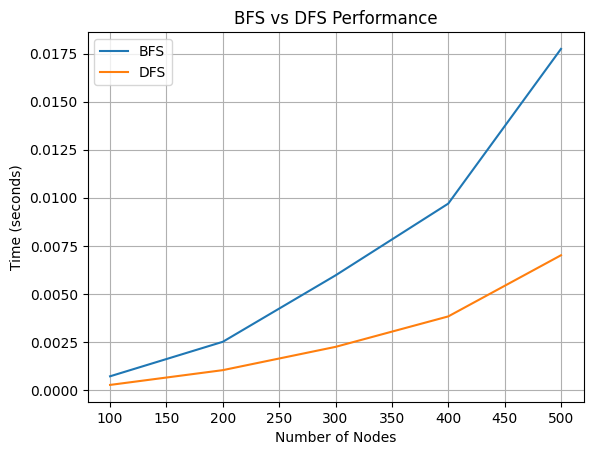

In [4]:
import time
import random
import matplotlib.pyplot as plt
from collections import deque

# It will generate random graph
def generate_graph(n):
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < 0.4:  
                graph[i].append(j)
                graph[j].append(i)
    return graph


# BFS
def bfs(graph, start):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                queue.append(neighbor)


# DFS
def dfs(graph, node, visited):
    visited.add(node)
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited)


# It will measure the time (start time - end time)
def measure_time(func, *args):
    start = time.perf_counter()
    func(*args)
    end = time.perf_counter()
    return end - start


def average_time(func, *args, runs=7):
    total = 0
    for _ in range(runs):
        total += measure_time(func, *args)
    return total / runs


sizes = [100, 200, 300, 400, 500]
bfs_times = []
dfs_times = []

for n in sizes:
    g = generate_graph(n)

    bfs_time = average_time(bfs, g, 0)
    dfs_time = average_time(lambda g, s: dfs(g, s, set()), g, 0)

    bfs_times.append(bfs_time)
    dfs_times.append(dfs_time)

plt.figure()
plt.plot(sizes, bfs_times, label="BFS")
plt.plot(sizes, dfs_times, label="DFS")
plt.xlabel("Number of Nodes")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Performance")
plt.legend()
plt.grid()
plt.show()

# Observation:
Both BFS and DFS exhibit similar time complexity O(V+E), as they traverse all nodes and edges.
However, BFS shows slightly higher execution time due to additional overhead of queue operations.
As the number of nodes increases, execution time for both algorithms increases gradually.

# Topological Sort (Task Scheduling)

In [5]:
def topological_sort(graph):
    visited = set()
    stack = []

    def dfs(node):
        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                dfs(neighbor)
            stack.append(node)

    for node in graph:
        dfs(node)

    return stack[::-1]

print("\nTopological Sort:")
print(topological_sort(graph))


Topological Sort:
['A', 'C', 'B', 'E', 'F', 'D']


# Dijkstra

In [6]:
import heapq

def dijkstra(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    
    pq = [(0, start)]

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        for neighbor, weight in graph[current_node]:
            distance = current_dist + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                heapq.heappush(pq, (distance, neighbor))

    return distances


weighted_graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 3)],
    'D': [],
    'E': [('F', 1)],
    'F': []
}

print("\nDijkstra Shortest Paths:")
print(dijkstra(weighted_graph, 'A'))


Dijkstra Shortest Paths:
{'A': 0, 'B': 1, 'C': 4, 'D': 3, 'E': 6, 'F': 7}


# Bellman-Ford

In [7]:
def bellman_ford(edges, vertices, start):
    dist = {v: float('inf') for v in vertices}
    dist[start] = 0

    for _ in range(len(vertices) - 1):
        for u, v, w in edges:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w

    return dist


edges = [
    ('A','B',1),
    ('A','C',4),
    ('B','D',2),
    ('B','E',5),
    ('C','F',3),
    ('E','F',1)
]

vertices = ['A','B','C','D','E','F']

print("\nBellman-Ford:")
print(bellman_ford(edges, vertices, 'A'))


Bellman-Ford:
{'A': 0, 'B': 1, 'C': 4, 'D': 3, 'E': 6, 'F': 7}


# Comparison of Dijkstra and Bellman Ford

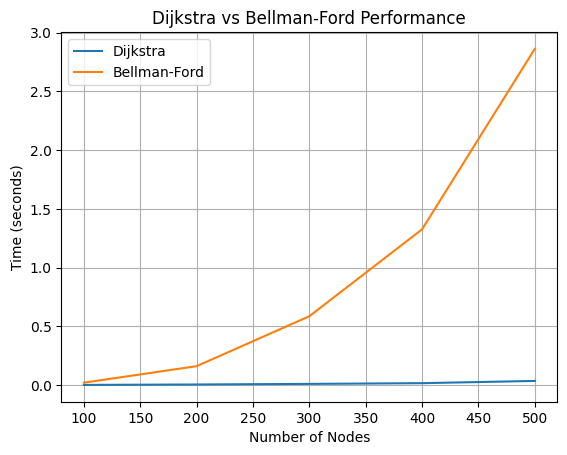

In [ ]:
import time
import random
import heapq
import matplotlib.pyplot as plt

# It will generate weighted graph
def generate_weighted_graph(n):
    graph = {i: [] for i in range(n)}
    edges = []

    for i in range(n):
        for j in range(i+1, n):
            if random.random() < 0.4:
                weight = random.randint(1, 10)
                graph[i].append((j, weight))
                graph[j].append((i, weight))
                edges.append((i, j, weight))

    return graph, edges


# Dijkstra
def dijkstra(graph, start):
    dist = {node: float('inf') for node in graph}
    dist[start] = 0
    pq = [(0, start)]

    while pq:
        d, node = heapq.heappop(pq)
        for neighbor, w in graph[node]:
            if d + w < dist[neighbor]:
                dist[neighbor] = d + w
                heapq.heappush(pq, (dist[neighbor], neighbor))


# Bellman-Ford
def bellman_ford(edges, n, start):
    dist = [float('inf')] * n
    dist[start] = 0

    for _ in range(n - 1):
        for u, v, w in edges:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w


def measure_time(func, *args):
    start = time.perf_counter()
    func(*args)
    end = time.perf_counter()
    return end - start


def average_time(func, *args, runs=5):
    total = 0
    for _ in range(runs):
        total += measure_time(func, *args)
    return total / runs


sizes = [100, 200, 300, 400, 500]
dijkstra_times = []
bellman_times = []

for n in sizes:
    graph, edges = generate_weighted_graph(n)

    d_time = average_time(dijkstra, graph, 0)
    b_time = average_time(bellman_ford, edges, n, 0)

    dijkstra_times.append(d_time)
    bellman_times.append(b_time)

plt.figure()
plt.plot(sizes, dijkstra_times, label="Dijkstra")
plt.plot(sizes, bellman_times, label="Bellman-Ford")
plt.xlabel("Number of Nodes")
plt.ylabel("Time (seconds)")
plt.title("Dijkstra vs Bellman-Ford Performance")
plt.legend()
plt.grid()
plt.show()

# Observation:
Dijkstra’s algorithm performs significantly faster than Bellman-Ford for graphs with non-negative weights.
This is because Dijkstra uses a priority queue which reduces the number of operations.
Bellman-Ford, on the other hand, relaxes all edges repeatedly, resulting in higher time complexity.
As the number of nodes increases, the execution time of Bellman-Ford increases rapidly compared to Dijkstra.

# MST (Prim’s Algorithm)

In [9]:
import heapq

def prim(graph, start):
    visited = set()
    min_heap = [(0, start)]
    total_cost = 0

    while min_heap:
        cost, node = heapq.heappop(min_heap)

        if node not in visited:
            visited.add(node)
            total_cost += cost

            for neighbor, weight in graph[node]:
                heapq.heappush(min_heap, (weight, neighbor))

    return total_cost


print("\nMST Cost:", prim(weighted_graph, 'A'))


MST Cost: 15
